[*********************100%***********************]  5 of 5 completed


Data shape: (1237, 5)
Ticker      RELIANCE.NS       TCS.NS  HDFCBANK.NS      INFY.NS  HINDUNILVR.NS
Date                                                                         
2021-03-01   952.976440  2570.596436   738.276001  1115.365723    1971.082275
2021-03-02   954.926208  2642.812744   742.680420  1148.377808    2002.854492
2021-03-03   998.500977  2689.184082   751.512817  1182.754517    2017.154419
2021-03-04   986.598328  2680.920898   735.031921  1171.134155    2020.281250
2021-03-05   987.890625  2644.307861   724.589355  1159.117676    2024.143677


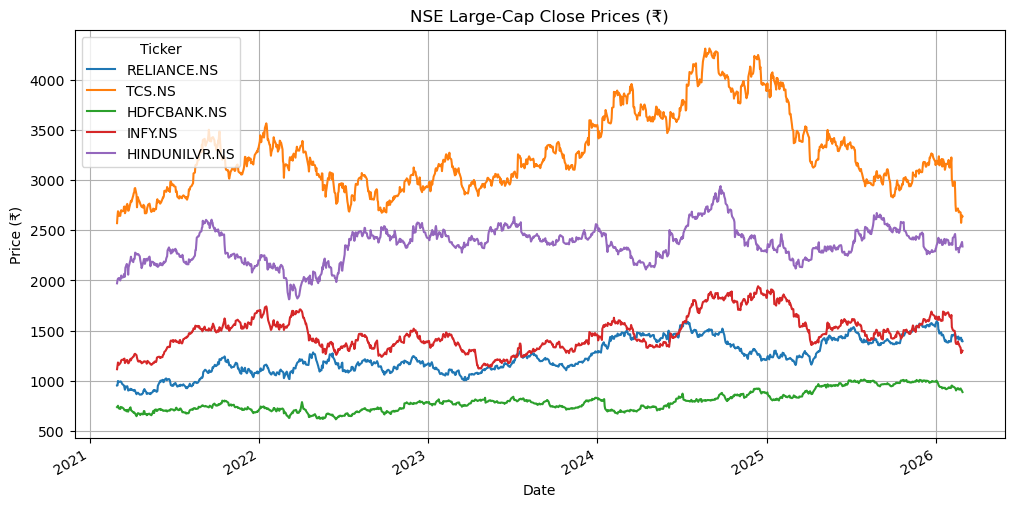

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib inline

tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'HINDUNILVR.NS']
start_date = '2021-03-01'
end_date = '2026-03-01'

raw_data = yf.download(tickers, start=start_date, end=end_date)

# Take 'Close' level from MultiIndex columns
data = raw_data.xs(key='Close', axis=1, level='Price')
data = data[tickers]  # ensure column order

print("Data shape:", data.shape)
print(data.head())

data.plot(figsize=(12,6), title='NSE Large-Cap Close Prices (₹)', grid=True)
plt.ylabel('Price (₹)')
plt.show()


Log returns shape: (1236, 5)
Ticker      RELIANCE.NS    TCS.NS  HDFCBANK.NS   INFY.NS  HINDUNILVR.NS
Date                                                                   
2021-03-02     0.002044  0.027706     0.005948  0.029168       0.015991
2021-03-03     0.044621  0.017394     0.011822  0.029496       0.007114
2021-03-04    -0.011992 -0.003077    -0.022174 -0.009873       0.001549
2021-03-05     0.001309 -0.013751    -0.014309 -0.010314       0.001910
2021-03-08     0.005675 -0.000366    -0.006886  0.014364      -0.012136

Mean daily returns:
 Ticker
RELIANCE.NS      0.000308
TCS.NS           0.000021
HDFCBANK.NS      0.000149
INFY.NS          0.000124
HINDUNILVR.NS    0.000138
dtype: float64

Daily volatility:
 Ticker
RELIANCE.NS      0.014076
TCS.NS           0.013240
HDFCBANK.NS      0.012937
INFY.NS          0.015375
HINDUNILVR.NS    0.012694
dtype: float64


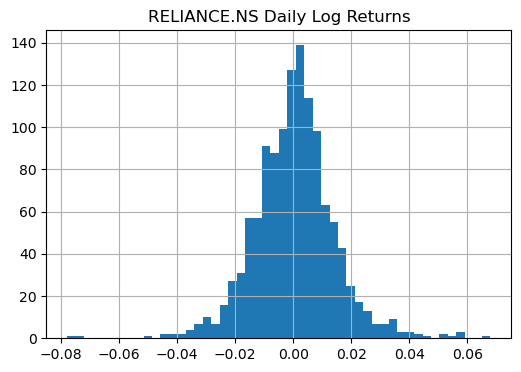

In [18]:
# Step 2: daily log returns
log_returns = np.log(data / data.shift(1))
log_returns = log_returns.dropna()

print("Log returns shape:", log_returns.shape)
print(log_returns.head())

# Quick check: basic stats
print("\nMean daily returns:\n", log_returns.mean())
print("\nDaily volatility:\n", log_returns.std())

# Optional: visualize one stock's returns
log_returns['RELIANCE.NS'].hist(bins=50, figsize=(6,4))
plt.title('RELIANCE.NS Daily Log Returns')
plt.show()


In [21]:
trading_days = 252
risk_free = 0.07  # 7% approx Indian risk-free

# Recompute for clarity
mean_daily = log_returns.mean()
cov_daily = log_returns.cov()

def portfolio_return(weights):
    # weights: numpy array of length 5, sums to 1
    return np.dot(weights, mean_daily) * trading_days  # annual return

def portfolio_volatility(weights):
    # annualized portfolio std dev
    return np.sqrt(np.dot(weights.T, np.dot(cov_daily * trading_days, weights)))

def portfolio_sharpe(weights, rf=risk_free):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    return (ret - rf) / vol


In [22]:
import numpy as np

w_eq = np.array([1/5] * 5)
print("Equal-weight portfolio:")
print("Annual return:", portfolio_return(w_eq))
print("Annual vol   :", portfolio_volatility(w_eq))
print("Sharpe       :", portfolio_sharpe(w_eq))


Equal-weight portfolio:
Annual return: 0.037282683809443884
Annual vol   : 0.14369763401920288
Sharpe       : -0.22768166235906137


In [23]:
num_ports = 5000
results = np.zeros((3, num_ports))  # rows: return, vol, sharpe
weights_record = []

for i in range(num_ports):
    w = np.random.random(len(tickers))
    w = w / w.sum()  # normalize to sum 1
    weights_record.append(w)

    ret = portfolio_return(w)
    vol = portfolio_volatility(w)
    sharpe = (ret - risk_free) / vol

    results[0, i] = ret
    results[1, i] = vol
    results[2, i] = sharpe

results_df = pd.DataFrame({
    'return': results[0],
    'vol': results[1],
    'sharpe': results[2]
})

print(results_df.describe())


            return          vol       sharpe
count  5000.000000  5000.000000  5000.000000
mean      0.037378     0.150843    -0.216664
std       0.006540     0.008664     0.042803
min       0.011405     0.137505    -0.325302
25%       0.032659     0.144325    -0.247978
50%       0.037458     0.149127    -0.217941
75%       0.041757     0.155605    -0.189654
max       0.063217     0.200366    -0.037151


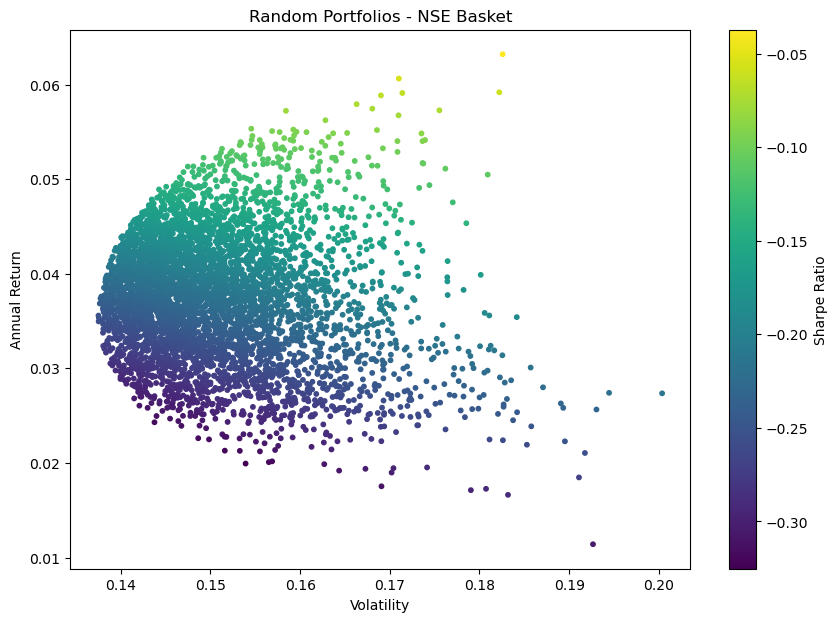

In [24]:
plt.figure(figsize=(10,7))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', s=10)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Annual Return')
plt.title('Random Portfolios - NSE Basket')
plt.show()


In [25]:
# Find index of max Sharpe
max_sharpe_idx = np.argmax(results[2])
best_ret = results[0, max_sharpe_idx]
best_vol = results[1, max_sharpe_idx]
best_sharpe = results[2, max_sharpe_idx]
best_weights = weights_record[max_sharpe_idx]

print("Best random portfolio:")
print("Return :", best_ret)
print("Vol    :", best_vol)
print("Sharpe :", best_sharpe)
print("\nWeights:")
for t, w in zip(tickers, best_weights):
    print(f"{t}: {w:.2%}")


Best random portfolio:
Return : 0.06321687995940571
Vol    : 0.18258160011125885
Sharpe : -0.037151169868491124

Weights:
RELIANCE.NS: 71.01%
TCS.NS: 5.77%
HDFCBANK.NS: 7.55%
INFY.NS: 12.15%
HINDUNILVR.NS: 3.53%


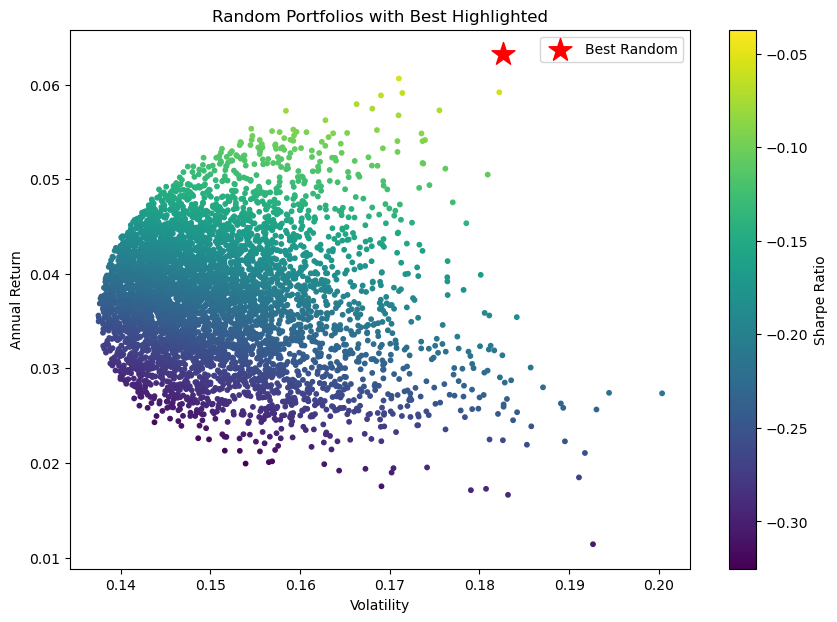

In [26]:
plt.figure(figsize=(10,7))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', s=10)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(best_vol, best_ret, color='red', marker='*', s=300, label='Best Random')
plt.xlabel('Volatility')
plt.ylabel('Annual Return')
plt.title('Random Portfolios with Best Highlighted')
plt.legend()
plt.show()


In [33]:
bounds = tuple((0, 0.4) for _ in range(len(tickers)))  # 0–100% each
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
init_guess = np.array([1/len(tickers)] * len(tickers))

def neg_sharpe(w, rf=risk_free):
    return -portfolio_sharpe(w, rf)

opt_result = minimize(neg_sharpe,
                      init_guess,
                      method='SLSQP',
                      bounds=bounds,
                      constraints=constraints)

opt_w = opt_result.x

print("Optimal (SciPy, max 40% each):")
for t, w in zip(tickers, opt_w):
    print(f"{t}: {w:.2%}")

opt_ret = portfolio_return(opt_w)
opt_vol = portfolio_volatility(opt_w)
opt_sharpe = portfolio_sharpe(opt_w)

print("\nReturn :", opt_ret)
print("Vol    :", opt_vol)
print("Sharpe :", opt_sharpe)


Optimal (SciPy, max 40% each):
RELIANCE.NS: 40.00%
TCS.NS: 0.00%
HDFCBANK.NS: 40.00%
INFY.NS: 20.00%
HINDUNILVR.NS: 0.00%

Return : 0.05229795362592832
Vol    : 0.1642834248296358
Sharpe : -0.10775308825238432


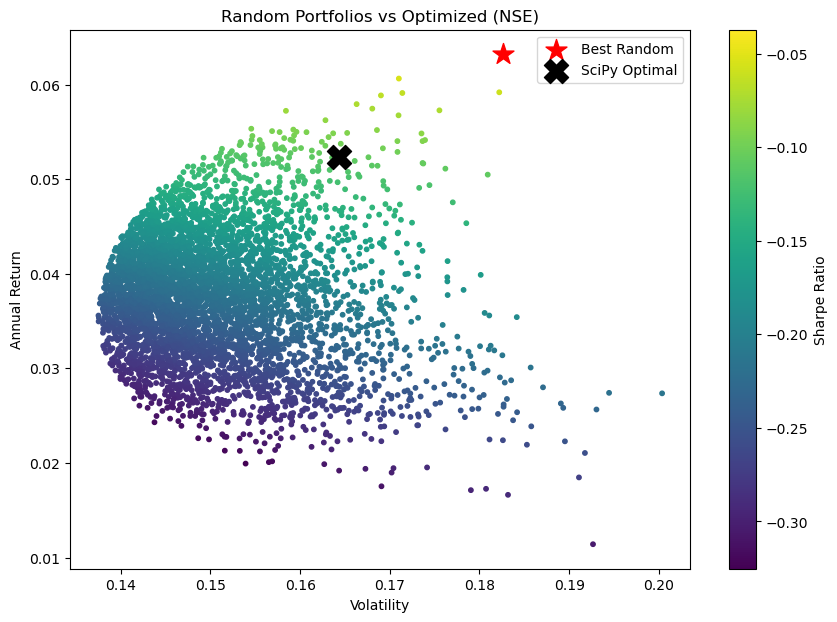

In [34]:
plt.figure(figsize=(10,7))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', s=10)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(best_vol, best_ret, color='red', marker='*', s=250, label='Best Random')
plt.scatter(opt_vol, opt_ret, color='black', marker='X', s=300, label='SciPy Optimal')
plt.xlabel('Volatility')
plt.ylabel('Annual Return')
plt.title('Random Portfolios vs Optimized (NSE)')
plt.legend()
plt.show()


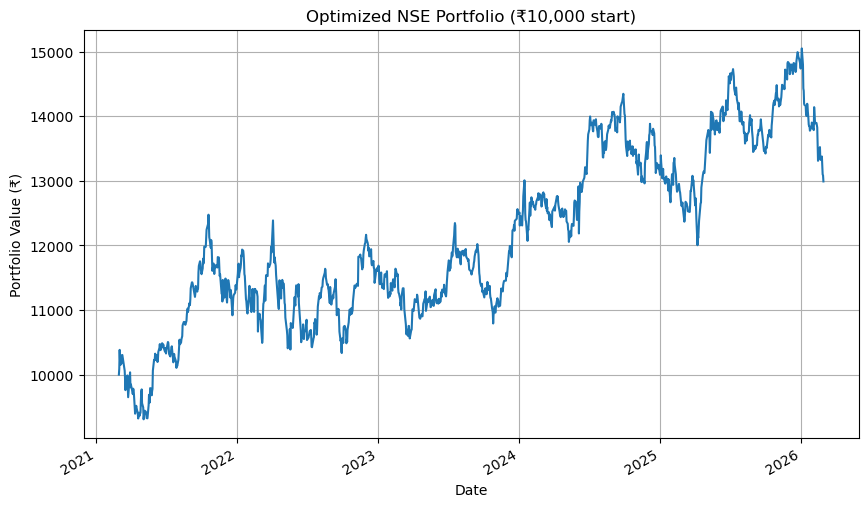

Total return over period: 0.29918294055226435
Backtested annual Sharpe: 0.40659810151353654


In [36]:
initial_capital = 10000

normed = data / data.iloc[0]
alloc = normed * opt_w
port_val = alloc.sum(axis=1) * initial_capital

port_val.plot(figsize=(10,6), title='Optimized NSE Portfolio (₹10,000 start)', grid=True)
plt.ylabel('Portfolio Value (₹)')
plt.show()

total_return = port_val.iloc[-1] / initial_capital - 1
daily_port_ret = port_val.pct_change().dropna()
ann_sharpe_bt = (daily_port_ret.mean() * 252) / (daily_port_ret.std() * np.sqrt(252))

print("Total return over period:", total_return)
print("Backtested annual Sharpe:", ann_sharpe_bt)
